<a href="https://colab.research.google.com/github/Akashsky123/Deep-Learning-Lab/blob/main/Experiment9_GAN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 9 - Generative Adversarial Networks
**Dataset:** Fashion-MNIST | **Models:** Vanilla GAN, DCGAN

In [1]:
!pip install wandb huggingface_hub -q

In [2]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: akashverma_25afi26 (akashverma_25afi26-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader
from huggingface_hub import HfApi, create_repo

# change to your huggingface username
HF_REPO = "Akashverma937/exp9-gans"

WANDB_PROJECT = "exp9-gans"
EPOCHS        = 5
BATCH_SIZE    = 128
LATENT_DIM    = 100
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["bce", "lsgan", "wgan"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vanilla", "dcgan"]

print(DEVICE)

cuda


### Dataset

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 207kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.0MB/s]

train: 60000  test: 10000


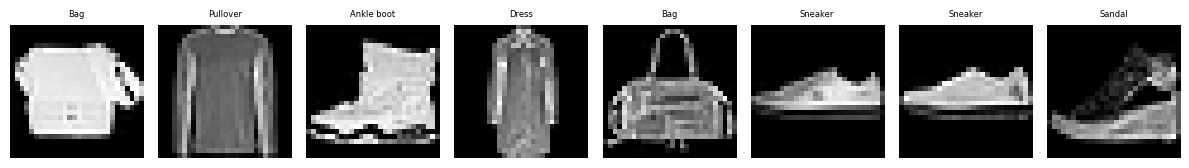

In [6]:
# normalize to [-1, 1] for GAN training
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_data = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'train: {len(train_data)}  test: {len(test_data)}')

imgs, labels = next(iter(train_loader))
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Vanilla GAN - Generator and Discriminator

In [7]:
class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(VanillaGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super(VanillaDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

### DCGAN - Generator and Discriminator

In [8]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(DCGenerator, self).__init__()
        self.net = nn.Sequential(
            # latent -> 7x7x256
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 7x7 -> 14x14
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 14x14 -> 28x28
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super(DCDiscriminator, self).__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14 -> 7x7
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 7x7 -> 1x1
            nn.Conv2d(128, 1, 7, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

### Loss Functions - BCE, LSGAN, WGAN

In [9]:
bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

def disc_loss(real_out, fake_out, loss_type):
    if loss_type == 'bce':
        real_loss = bce(real_out, torch.ones_like(real_out))
        fake_loss = bce(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'lsgan':
        real_loss = mse(real_out, torch.ones_like(real_out))
        fake_loss = mse(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'wgan':
        return -(real_out.mean() - fake_out.mean())

def gen_loss(fake_out, loss_type):
    if loss_type == 'bce':
        return bce(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'lsgan':
        return mse(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'wgan':
        return -fake_out.mean()

### Optimizer Factory

In [10]:
def get_optimizer(model, name):
    if name == 'adam':
        # betas tuned for GAN stability
        return optim.Adam(model.parameters(), lr=2e-4, betas=(0.5, 0.999))
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    else:
        return optim.RMSprop(model.parameters(), lr=5e-5)

### Training Loop

In [11]:
def train_epoch(G, D, loader, opt_g, opt_d, loss_type):
    G.train(); D.train()
    g_running = 0
    d_running = 0

    for real, _ in loader:
        real = real.to(DEVICE)
        bs   = real.size(0)

        # train discriminator
        z         = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake      = G(z).detach()
        real_out  = D(real)
        fake_out  = D(fake)
        d_loss    = disc_loss(real_out, fake_out, loss_type)
        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()

        # weight clipping for wgan
        if loss_type == 'wgan':
            for p in D.parameters():
                p.data.clamp_(-0.01, 0.01)

        # train generator
        z        = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake     = G(z)
        fake_out = D(fake)
        g_loss   = gen_loss(fake_out, loss_type)
        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

        g_running += g_loss.item()
        d_running += d_loss.item()

    n = len(loader)
    return g_running / n, d_running / n

### Visualization

In [12]:
def show_generated(G, epoch, tag, n=16):
    G.eval()
    with torch.no_grad():
        z    = torch.randn(n, LATENT_DIM).to(DEVICE)
        imgs = G(z).cpu()
    imgs = (imgs + 1) / 2  # [-1,1] -> [0,1]
    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'epoch {epoch} - {tag}', fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

### Main Experiment Runner

In [13]:
results       = {}
saved_generators = {}

def run_experiment(arch, loss_type, opt_name):
    name = f'{arch}_{loss_type}_{opt_name}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type, 'optimizer': opt_name, 'epochs': EPOCHS
    })

    if arch == 'vanilla':
        G = VanillaGenerator(LATENT_DIM).to(DEVICE)
        D = VanillaDiscriminator().to(DEVICE)
    else:
        G = DCGenerator(LATENT_DIM).to(DEVICE)
        D = DCDiscriminator().to(DEVICE)

    opt_g = get_optimizer(G, opt_name)
    opt_d = get_optimizer(D, opt_name)

    g_losses = []
    d_losses = []

    for epoch in range(1, EPOCHS + 1):
        g_loss, d_loss = train_epoch(G, D, train_loader, opt_g, opt_d, loss_type)
        g_losses.append(g_loss)
        d_losses.append(d_loss)
        wandb.log({'epoch': epoch, 'g_loss': g_loss, 'd_loss': d_loss})
        print(f'  epoch {epoch}/{EPOCHS}  g_loss={g_loss:.4f}  d_loss={d_loss:.4f}')

        if epoch % 5 == 0 or epoch == EPOCHS:
            fig = show_generated(G, epoch, name)
            wandb.log({f'generated_ep{epoch}': wandb.Image(fig)})
            plt.close(fig)

    # loss curves
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(g_losses, label='generator')
    ax.plot(d_losses, label='discriminator')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title(name)
    ax.legend()
    plt.tight_layout()
    plt.show()
    wandb.log({'loss_curve': wandb.Image(fig)})
    plt.close(fig)

    torch.save(G.state_dict(), f'{name}_G.pt')
    torch.save(D.state_dict(), f'{name}_D.pt')
    saved_generators[name] = G
    results[name] = {'g_loss': g_losses[-1], 'd_loss': d_losses[-1]}

    wandb.finish()
    return G, D

### Quick Test - run this first


starting: vanilla_bce_adam


  epoch 1/5  g_loss=1.1417  d_loss=0.4781
  epoch 2/5  g_loss=1.8982  d_loss=0.4496
  epoch 3/5  g_loss=2.1501  d_loss=0.4123
  epoch 4/5  g_loss=2.1017  d_loss=0.4288
  epoch 5/5  g_loss=1.7708  d_loss=0.4783


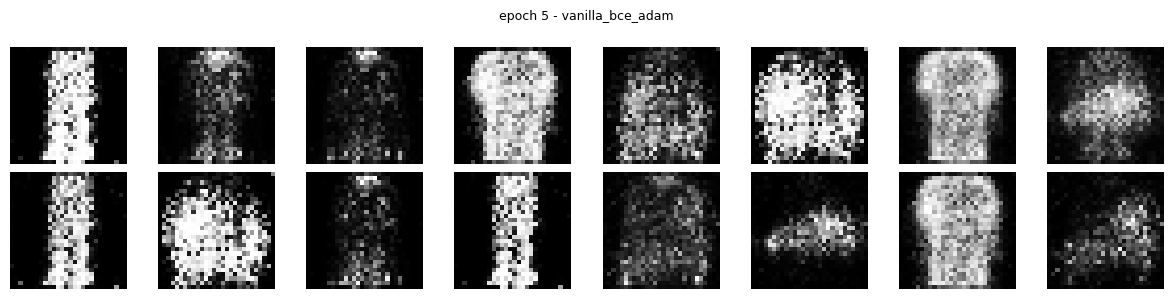

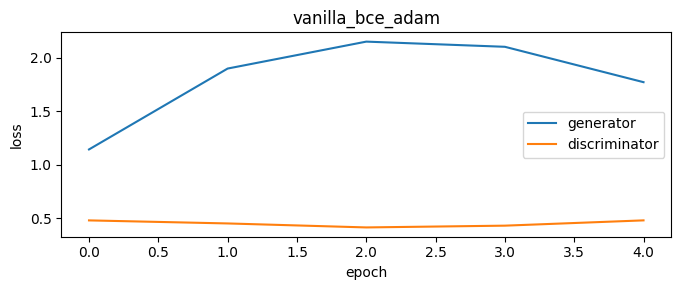

d_loss,█▅▁▃█
epoch,▁▃▅▆█
g_loss,▁▆██▅
d_loss,0.47829
epoch,5
g_loss,1.77084



starting: dcgan_bce_adam


  epoch 1/5  g_loss=1.4934  d_loss=0.3833
  epoch 2/5  g_loss=1.3557  d_loss=0.4087
  epoch 3/5  g_loss=1.2139  d_loss=0.4774
  epoch 4/5  g_loss=1.1752  d_loss=0.4960
  epoch 5/5  g_loss=1.1753  d_loss=0.4982


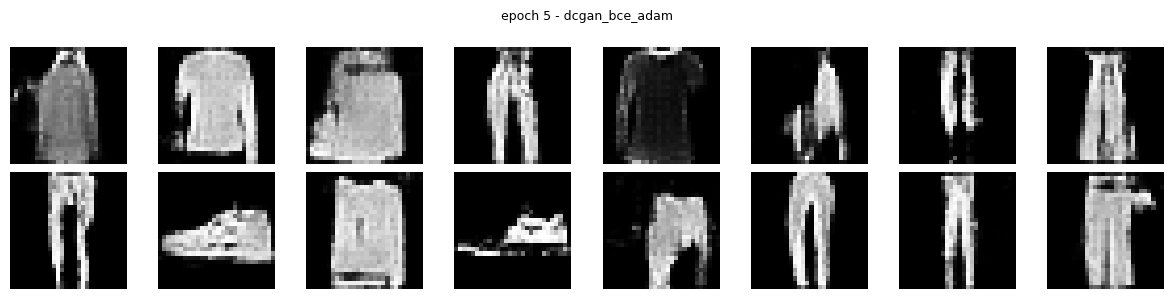

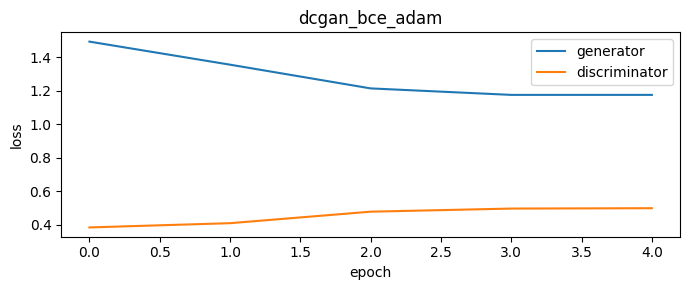

d_loss,▁▃▇██
epoch,▁▃▅▆█
g_loss,█▅▂▁▁
d_loss,0.49817
epoch,5
g_loss,1.17525


(DCGenerator(
   (net): Sequential(
     (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
     (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU(inplace=True)
     (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (5): ReLU(inplace=True)
     (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (7): Tanh()
   )
 ),
 DCDiscriminator(
   (net): Sequential(
     (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (1): LeakyReLU(negative_slope=0.2, inplace=True)
     (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (4): LeakyReLU(negative_slope=0.2, inplace=True)
    

In [14]:
run_experiment('vanilla', 'bce', 'adam')
run_experiment('dcgan',   'bce', 'adam')

### Full Grid - all combinations


starting: vanilla_bce_adam


  epoch 1/5  g_loss=1.1416  d_loss=0.4811
  epoch 2/5  g_loss=1.7547  d_loss=0.4668
  epoch 3/5  g_loss=1.8317  d_loss=0.4945
  epoch 4/5  g_loss=1.5300  d_loss=0.5203
  epoch 5/5  g_loss=1.3854  d_loss=0.5567


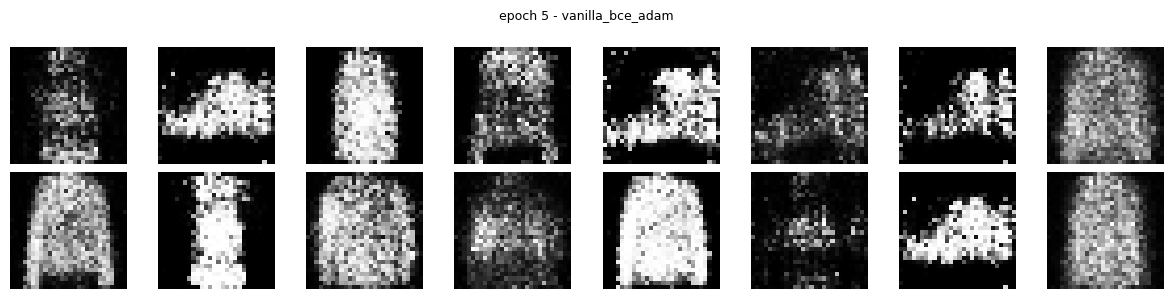

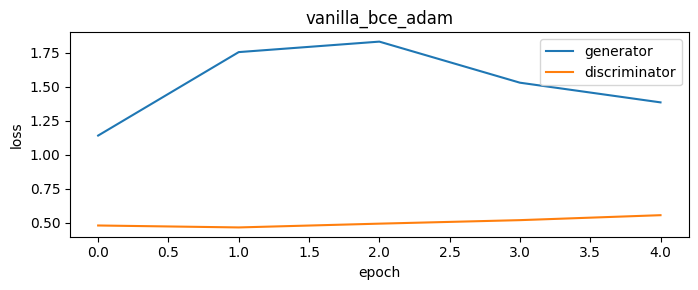

d_loss,▂▁▃▅█
epoch,▁▃▅▆█
g_loss,▁▇█▅▃
d_loss,0.55672
epoch,5
g_loss,1.38538



starting: vanilla_bce_sgd


  epoch 1/5  g_loss=0.8031  d_loss=0.3745
  epoch 2/5  g_loss=1.5681  d_loss=0.2878
  epoch 3/5  g_loss=2.4376  d_loss=0.1655
  epoch 4/5  g_loss=2.7817  d_loss=0.1535
  epoch 5/5  g_loss=2.9723  d_loss=0.1651


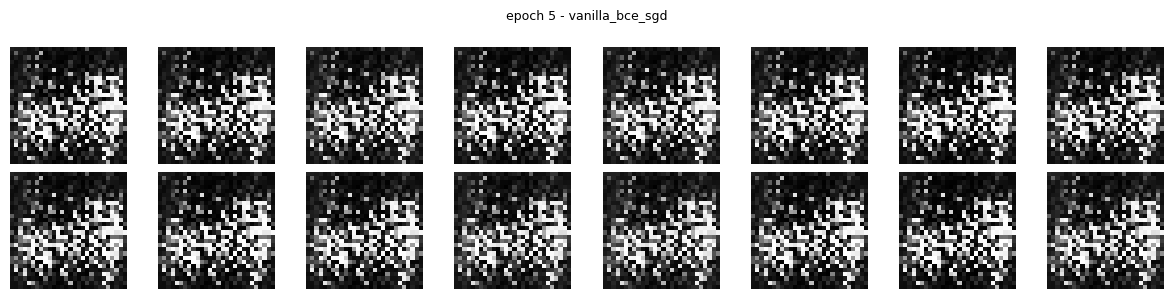

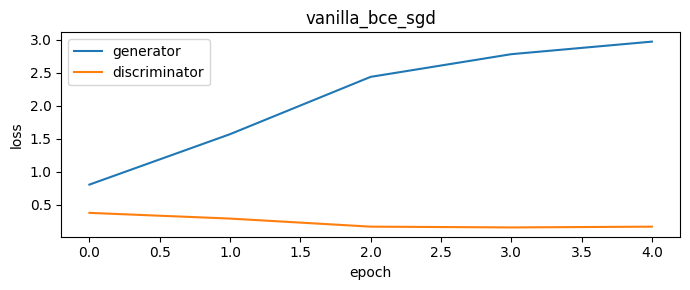

d_loss,█▅▁▁▁
epoch,▁▃▅▆█
g_loss,▁▃▆▇█
d_loss,0.16514
epoch,5
g_loss,2.97227



starting: vanilla_bce_rmsprop


  epoch 1/5  g_loss=0.9026  d_loss=0.4548
  epoch 2/5  g_loss=1.4392  d_loss=0.3648
  epoch 3/5  g_loss=2.0358  d_loss=0.2970
  epoch 4/5  g_loss=2.4230  d_loss=0.2721
  epoch 5/5  g_loss=2.7241  d_loss=0.2332


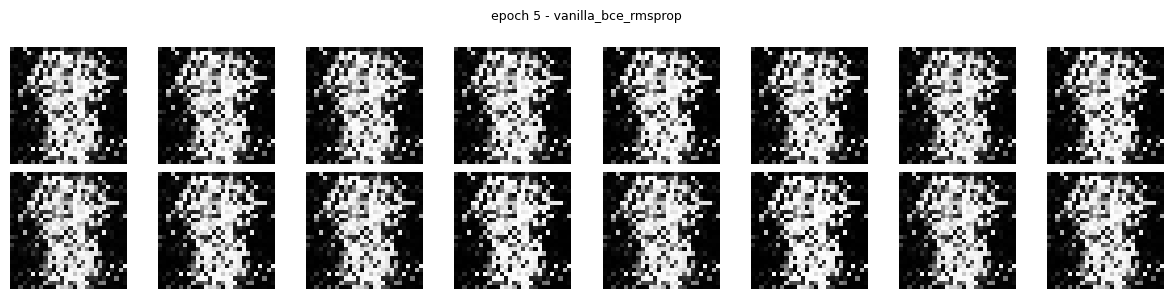

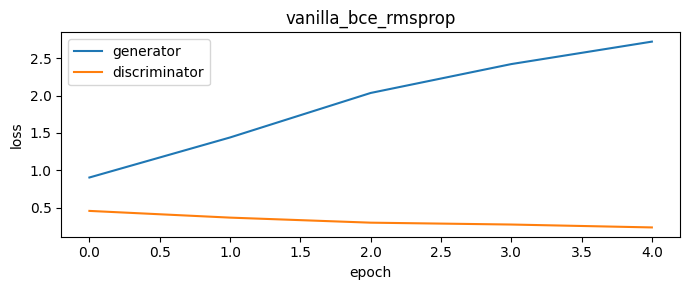

d_loss,█▅▃▂▁
epoch,▁▃▅▆█
g_loss,▁▃▅▇█
d_loss,0.23323
epoch,5
g_loss,2.72408



starting: vanilla_lsgan_adam


  epoch 1/5  g_loss=0.9795  d_loss=0.0734
  epoch 2/5  g_loss=0.9035  d_loss=0.0924
  epoch 3/5  g_loss=0.7632  d_loss=0.1376
  epoch 4/5  g_loss=0.6541  d_loss=0.1530
  epoch 5/5  g_loss=0.5631  d_loss=0.1716


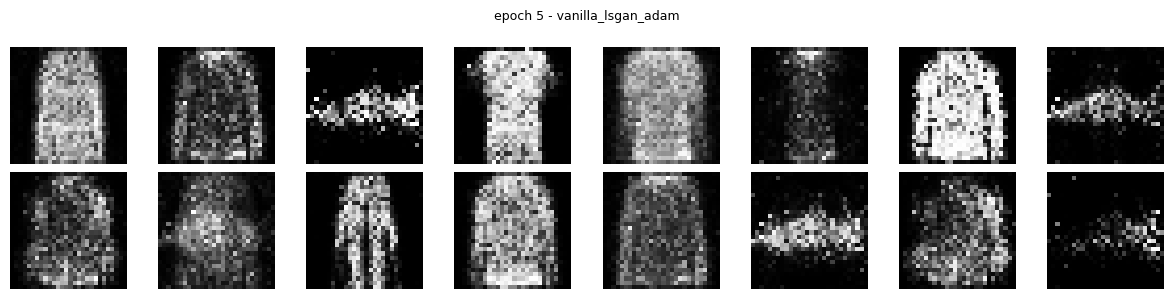

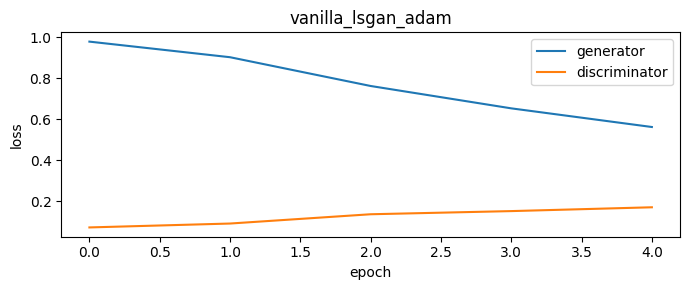

d_loss,▁▂▆▇█
epoch,▁▃▅▆█
g_loss,█▇▄▃▁
d_loss,0.17163
epoch,5
g_loss,0.56313



starting: vanilla_lsgan_sgd


  epoch 1/5  g_loss=0.7104  d_loss=0.0366
  epoch 2/5  g_loss=0.9897  d_loss=0.0318
  epoch 3/5  g_loss=0.9871  d_loss=0.0226
  epoch 4/5  g_loss=0.9804  d_loss=0.0249
  epoch 5/5  g_loss=0.9474  d_loss=0.0263


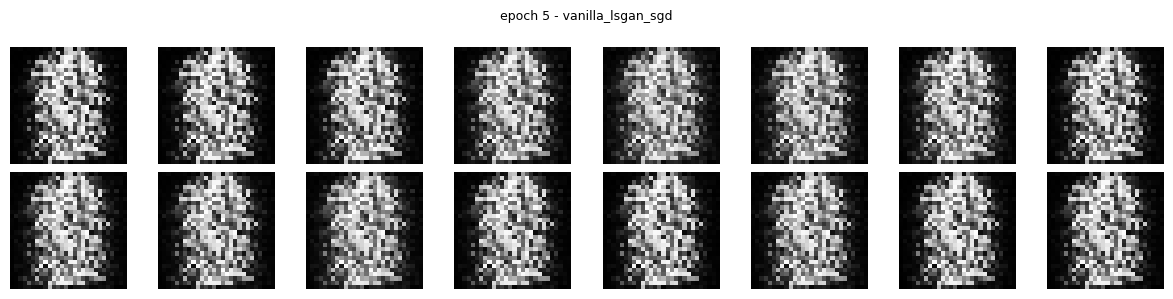

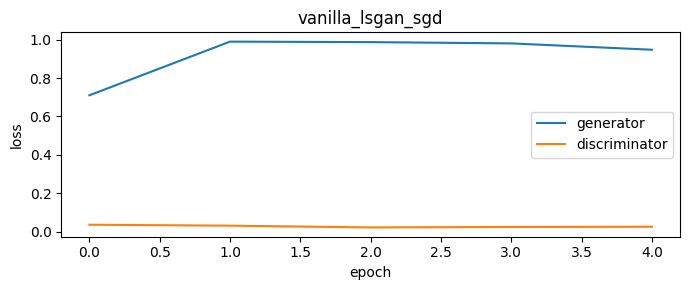

d_loss,█▆▁▂▃
epoch,▁▃▅▆█
g_loss,▁███▇
d_loss,0.02625
epoch,5
g_loss,0.94744



starting: vanilla_lsgan_rmsprop


  epoch 1/5  g_loss=0.8803  d_loss=0.0653
  epoch 2/5  g_loss=0.9559  d_loss=0.0723
  epoch 3/5  g_loss=0.9102  d_loss=0.0850
  epoch 4/5  g_loss=0.9300  d_loss=0.0865
  epoch 5/5  g_loss=0.9022  d_loss=0.0881


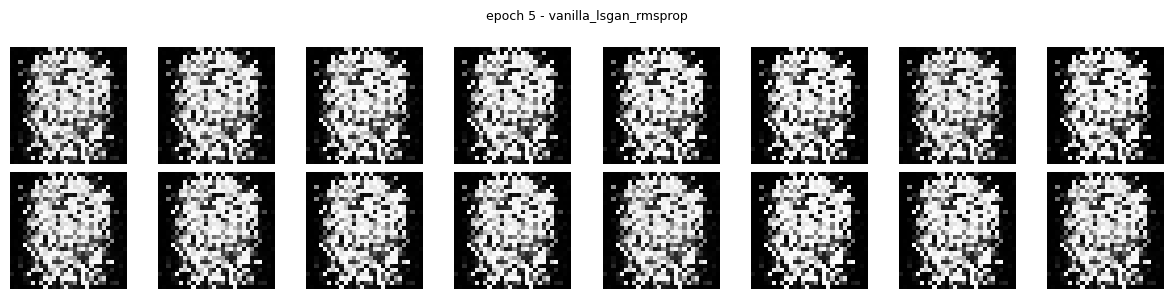

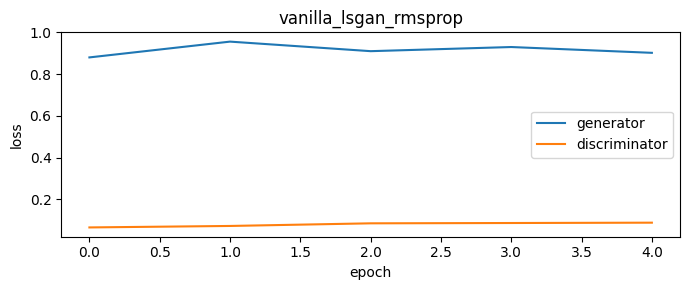

d_loss,▁▃▇██
epoch,▁▃▅▆█
g_loss,▁█▄▆▃
d_loss,0.08807
epoch,5
g_loss,0.90223



starting: vanilla_wgan_adam


  epoch 1/5  g_loss=-0.2412  d_loss=-0.3040
  epoch 2/5  g_loss=-0.4403  d_loss=-0.3184
  epoch 3/5  g_loss=0.0297  d_loss=-0.4336
  epoch 4/5  g_loss=-0.3547  d_loss=-0.2363
  epoch 5/5  g_loss=-0.3698  d_loss=-0.3928


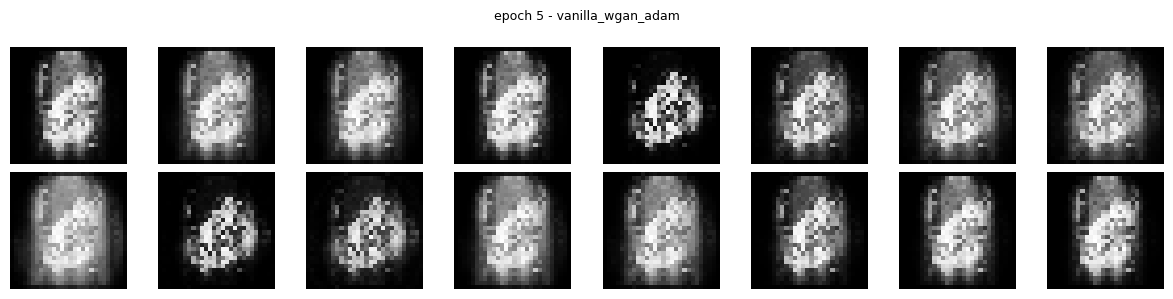

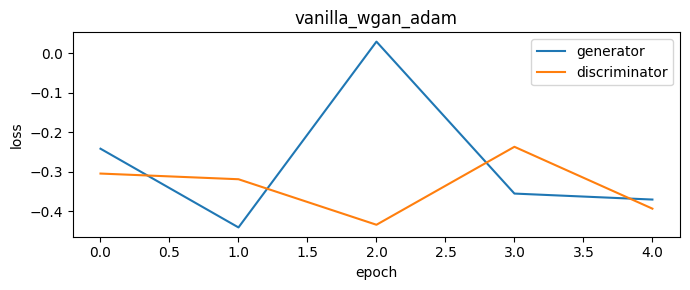

d_loss,▆▅▁█▂
epoch,▁▃▅▆█
g_loss,▄▁█▂▂
d_loss,-0.39282
epoch,5
g_loss,-0.36979



starting: vanilla_wgan_sgd


  epoch 1/5  g_loss=-0.1971  d_loss=-1.9100
  epoch 2/5  g_loss=2.2038  d_loss=-0.6507
  epoch 3/5  g_loss=2.9588  d_loss=-0.7781
  epoch 4/5  g_loss=-1.3728  d_loss=-2.6803
  epoch 5/5  g_loss=2.9979  d_loss=-1.1345


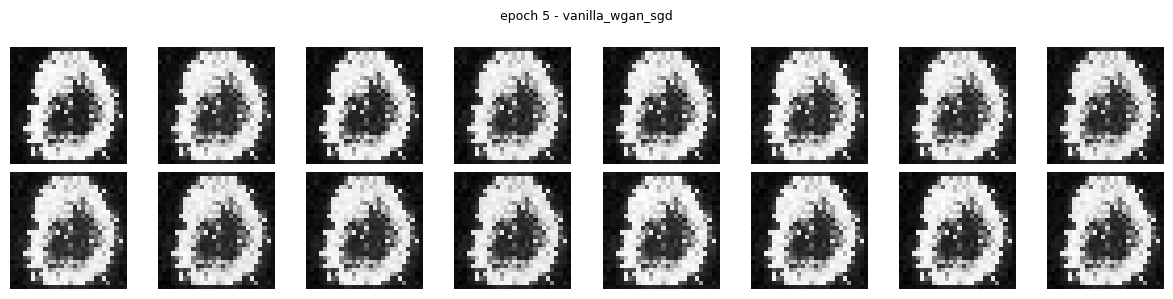

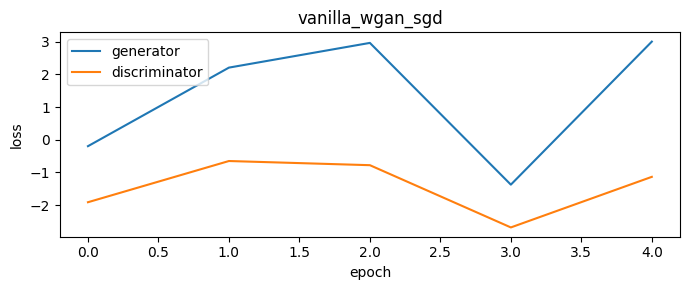

d_loss,▄██▁▆
epoch,▁▃▅▆█
g_loss,▃▇█▁█
d_loss,-1.13451
epoch,5
g_loss,2.99793



starting: vanilla_wgan_rmsprop


  epoch 1/5  g_loss=-0.0621  d_loss=-0.1494
  epoch 2/5  g_loss=-0.1385  d_loss=-0.3811
  epoch 3/5  g_loss=-0.6252  d_loss=-0.2699
  epoch 4/5  g_loss=-0.3689  d_loss=-0.3083
  epoch 5/5  g_loss=-0.4233  d_loss=-0.4795


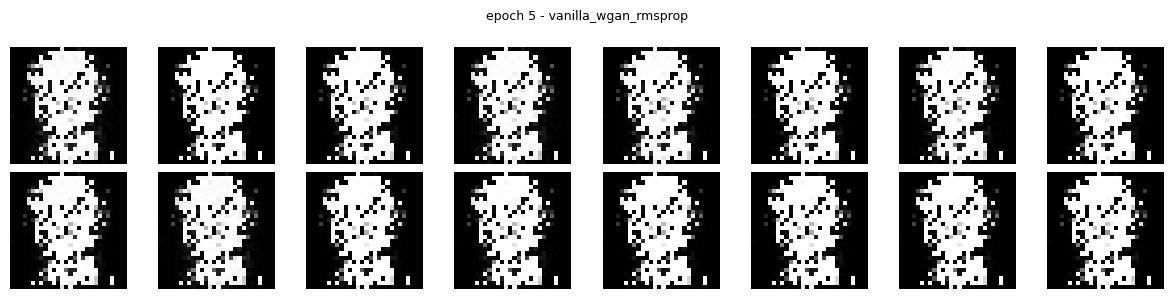

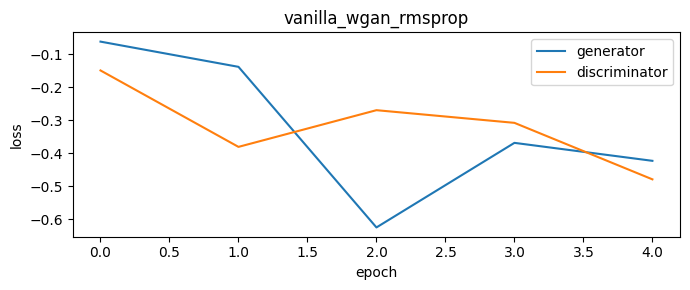

d_loss,█▃▅▅▁
epoch,▁▃▅▆█
g_loss,█▇▁▄▄
d_loss,-0.47946
epoch,5
g_loss,-0.42335



starting: dcgan_bce_adam


  epoch 1/5  g_loss=5.9325  d_loss=0.0244
  epoch 2/5  g_loss=2.2065  d_loss=0.3685
  epoch 3/5  g_loss=1.3564  d_loss=0.4226
  epoch 4/5  g_loss=1.3793  d_loss=0.4497
  epoch 5/5  g_loss=1.4476  d_loss=0.4430


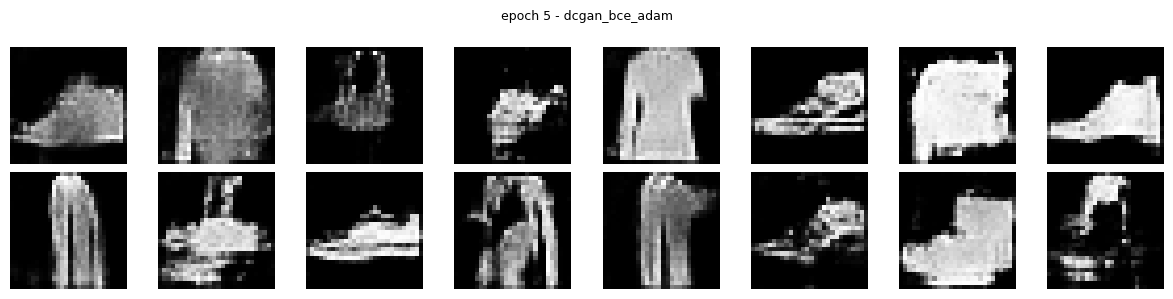

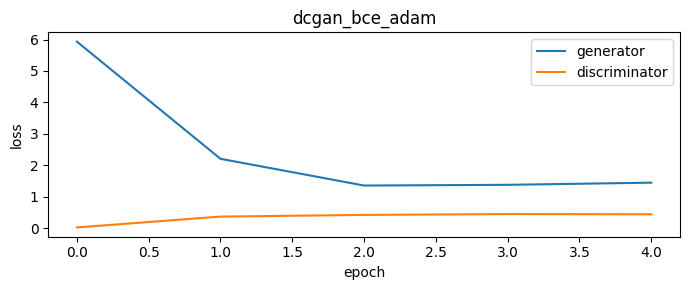

d_loss,▁▇███
epoch,▁▃▅▆█
g_loss,█▂▁▁▁
d_loss,0.44301
epoch,5
g_loss,1.44765



starting: dcgan_bce_sgd


  epoch 1/5  g_loss=8.5210  d_loss=0.0306
  epoch 2/5  g_loss=9.4539  d_loss=0.0033
  epoch 3/5  g_loss=8.6794  d_loss=0.0004
  epoch 4/5  g_loss=8.5725  d_loss=0.0003
  epoch 5/5  g_loss=9.0509  d_loss=0.0003


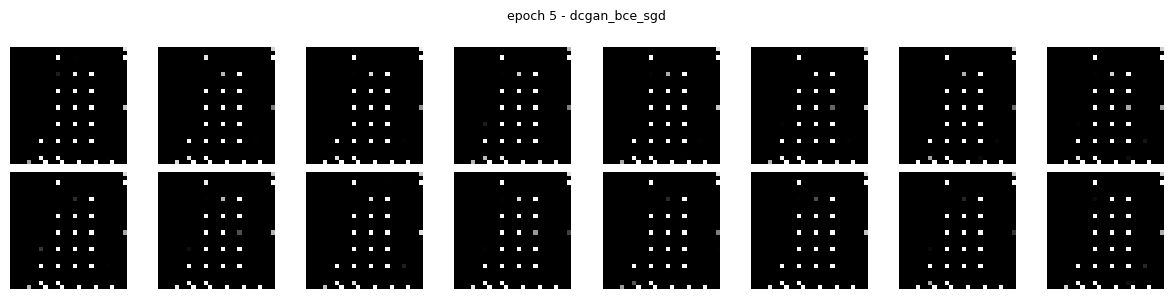

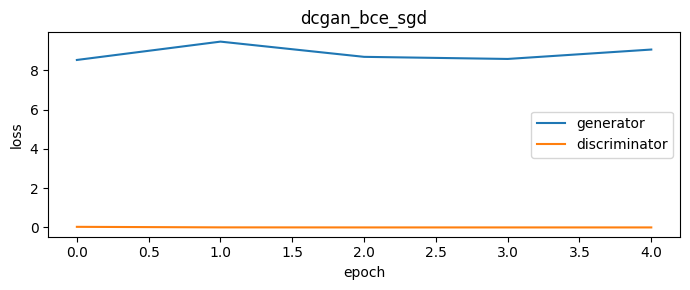

d_loss,█▂▁▁▁
epoch,▁▃▅▆█
g_loss,▁█▂▁▅
d_loss,0.00025
epoch,5
g_loss,9.05086



starting: dcgan_bce_rmsprop


  epoch 1/5  g_loss=4.8597  d_loss=0.0345
  epoch 2/5  g_loss=8.3956  d_loss=0.0004
  epoch 3/5  g_loss=7.4750  d_loss=0.0174
  epoch 4/5  g_loss=1.4309  d_loss=0.4438
  epoch 5/5  g_loss=1.5132  d_loss=0.3119


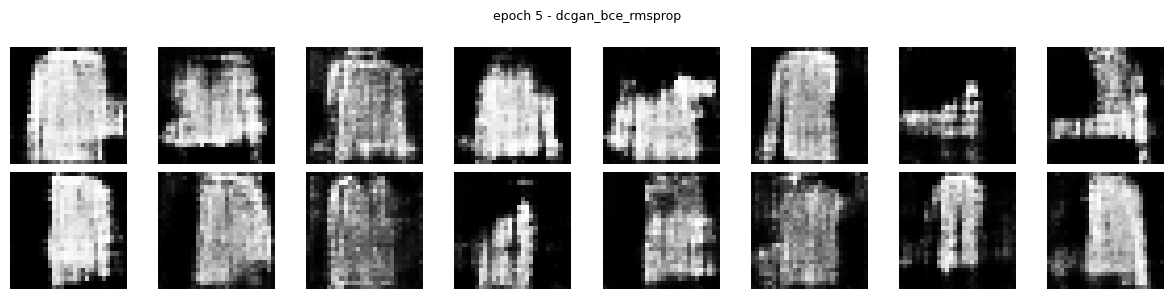

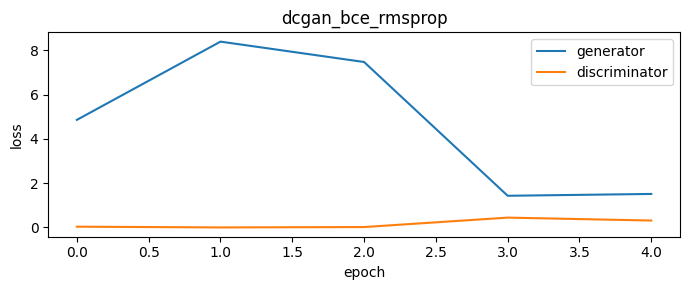

d_loss,▂▁▁█▆
epoch,▁▃▅▆█
g_loss,▄█▇▁▁
d_loss,0.31193
epoch,5
g_loss,1.51316



starting: dcgan_lsgan_adam


  epoch 1/5  g_loss=0.6350  d_loss=0.1612
  epoch 2/5  g_loss=0.5752  d_loss=0.1417
  epoch 3/5  g_loss=0.4992  d_loss=0.1705
  epoch 4/5  g_loss=0.4535  d_loss=0.1861
  epoch 5/5  g_loss=0.4423  d_loss=0.1969


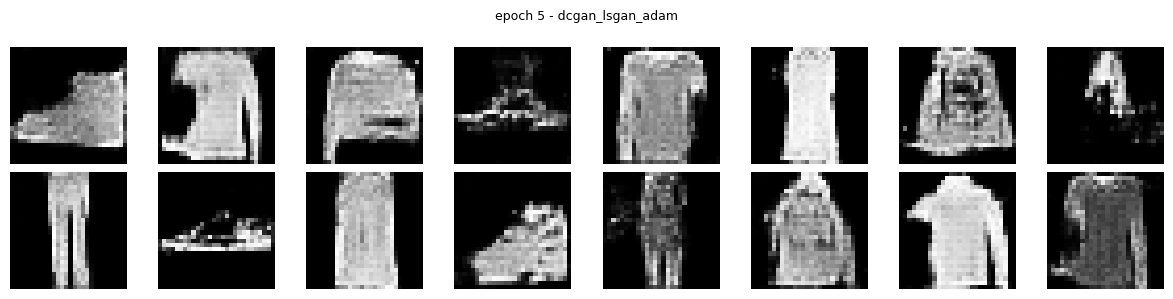

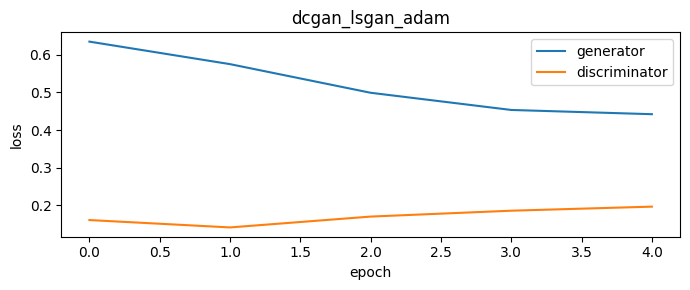

d_loss,▃▁▅▇█
epoch,▁▃▅▆█
g_loss,█▆▃▁▁
d_loss,0.19686
epoch,5
g_loss,0.4423



starting: dcgan_lsgan_sgd


  epoch 1/5  g_loss=1.3104  d_loss=0.1593
  epoch 2/5  g_loss=1.0154  d_loss=0.0050
  epoch 3/5  g_loss=1.0271  d_loss=0.0056
  epoch 4/5  g_loss=1.0316  d_loss=0.0046
  epoch 5/5  g_loss=1.0123  d_loss=0.0024


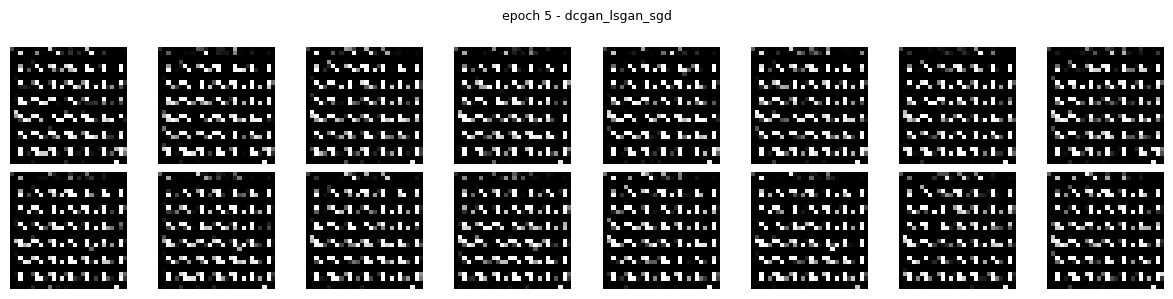

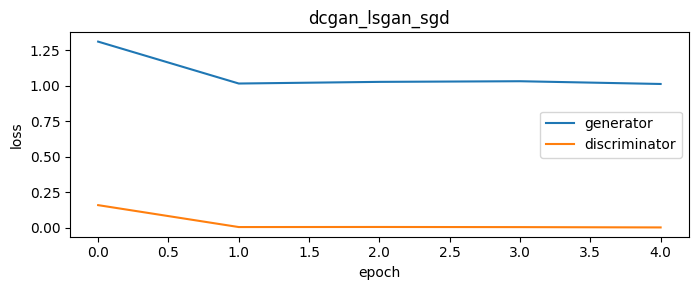

d_loss,█▁▁▁▁
epoch,▁▃▅▆█
g_loss,█▁▁▁▁
d_loss,0.0024
epoch,5
g_loss,1.01227



starting: dcgan_lsgan_rmsprop


  epoch 1/5  g_loss=0.5557  d_loss=0.1863
  epoch 2/5  g_loss=0.6121  d_loss=0.1139
  epoch 3/5  g_loss=0.6592  d_loss=0.0981
  epoch 4/5  g_loss=0.5787  d_loss=0.1229
  epoch 5/5  g_loss=0.5324  d_loss=0.1423


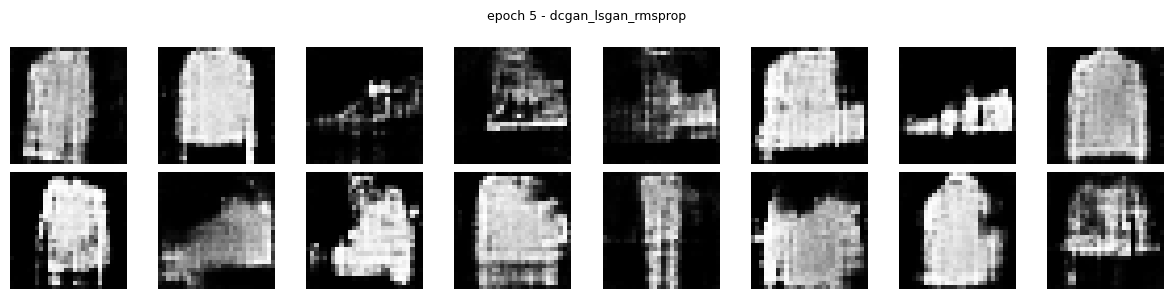

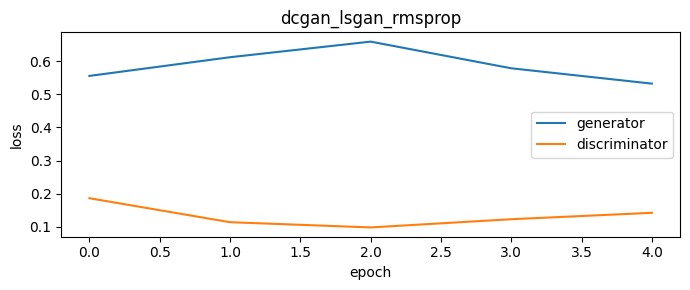

d_loss,█▂▁▃▅
epoch,▁▃▅▆█
g_loss,▂▅█▄▁
d_loss,0.14225
epoch,5
g_loss,0.53241



starting: dcgan_wgan_adam


  epoch 1/5  g_loss=-0.0076  d_loss=-0.0013
  epoch 2/5  g_loss=-0.0023  d_loss=-0.0036
  epoch 3/5  g_loss=-0.0043  d_loss=-0.0077
  epoch 4/5  g_loss=-0.0147  d_loss=-0.0055
  epoch 5/5  g_loss=-0.0141  d_loss=-0.0042


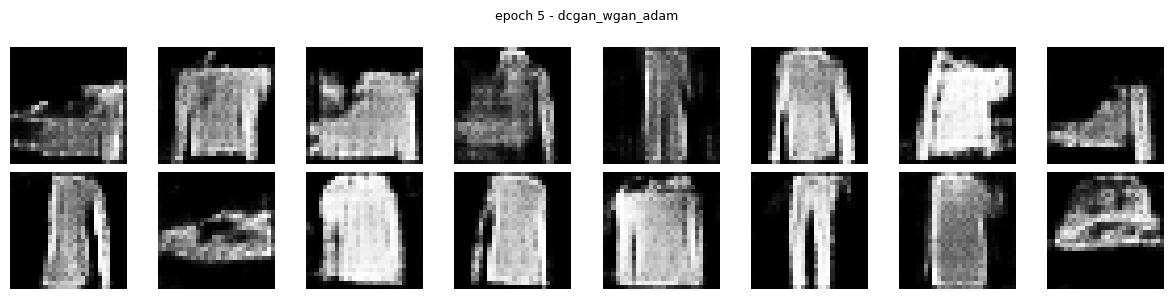

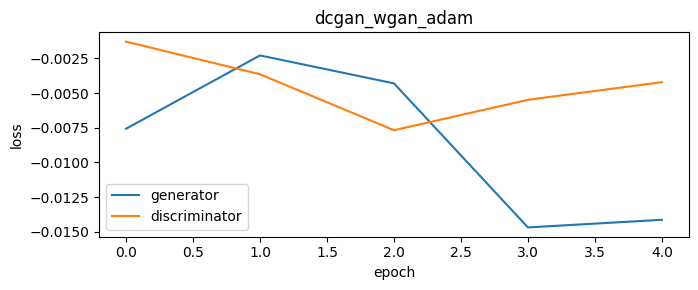

d_loss,█▅▁▃▅
epoch,▁▃▅▆█
g_loss,▅█▇▁▁
d_loss,-0.00421
epoch,5
g_loss,-0.01413



starting: dcgan_wgan_sgd


  epoch 1/5  g_loss=0.0322  d_loss=-0.1561
  epoch 2/5  g_loss=0.3608  d_loss=-0.5958
  epoch 3/5  g_loss=0.4329  d_loss=-0.6144
  epoch 4/5  g_loss=0.4405  d_loss=-0.6998
  epoch 5/5  g_loss=0.4234  d_loss=-0.5751


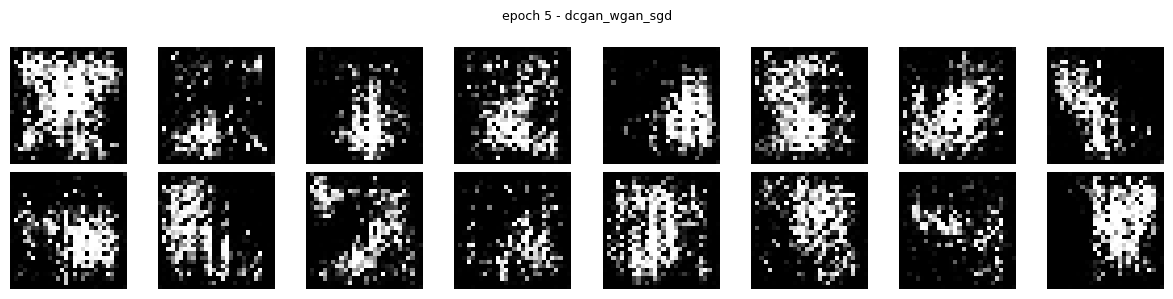

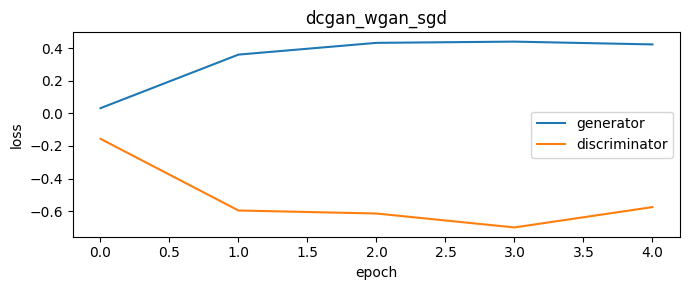

d_loss,█▂▂▁▃
epoch,▁▃▅▆█
g_loss,▁▇███
d_loss,-0.57506
epoch,5
g_loss,0.42335



starting: dcgan_wgan_rmsprop


  epoch 1/5  g_loss=0.0063  d_loss=-0.0186
  epoch 2/5  g_loss=0.0238  d_loss=-0.0163
  epoch 3/5  g_loss=0.0371  d_loss=-0.0340
  epoch 4/5  g_loss=0.0344  d_loss=-0.0302
  epoch 5/5  g_loss=0.0306  d_loss=-0.0236


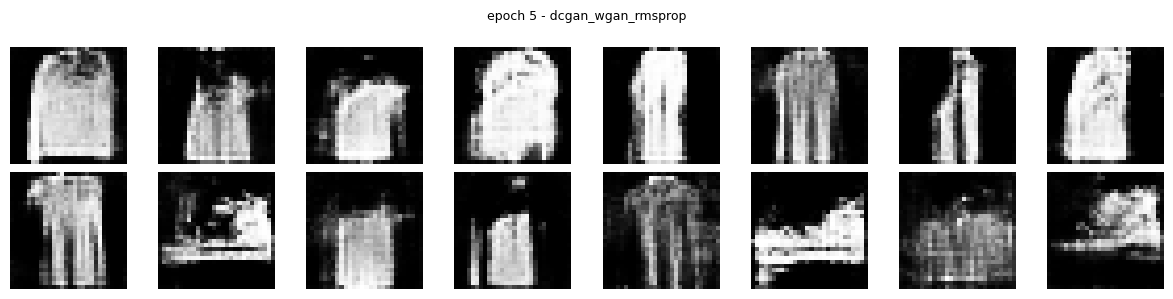

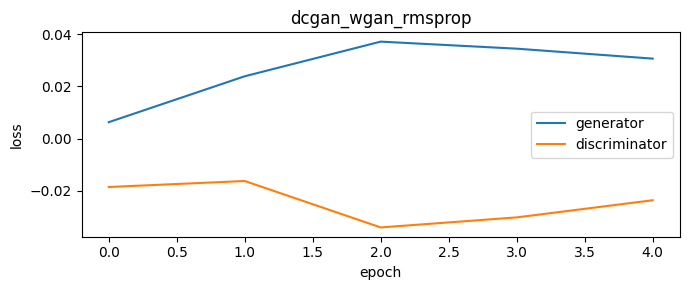

d_loss,▇█▁▃▅
epoch,▁▃▅▆█
g_loss,▁▅█▇▇
d_loss,-0.02363
epoch,5
g_loss,0.03059


In [15]:
for arch in MODELS:
    for lf in LOSS_FNS:
        for opt in OPTIMIZERS:
            run_experiment(arch, lf, opt)

### Results Summary

In [16]:
print(f'{"config":<35} {"g_loss":>10} {"d_loss":>10}')
print('-' * 57)
for k, v in sorted(results.items(), key=lambda x: x[1]['g_loss']):
    print(f'{k:<35} {v["g_loss"]:>10.4f} {v["d_loss"]:>10.4f}')

config                                  g_loss     d_loss
---------------------------------------------------------
vanilla_wgan_rmsprop                   -0.4233    -0.4795
vanilla_wgan_adam                      -0.3698    -0.3928
dcgan_wgan_adam                        -0.0141    -0.0042
dcgan_wgan_rmsprop                      0.0306    -0.0236
dcgan_wgan_sgd                          0.4234    -0.5751
dcgan_lsgan_adam                        0.4423     0.1969
dcgan_lsgan_rmsprop                     0.5324     0.1423
vanilla_lsgan_adam                      0.5631     0.1716
vanilla_lsgan_rmsprop                   0.9022     0.0881
vanilla_lsgan_sgd                       0.9474     0.0263
dcgan_lsgan_sgd                         1.0123     0.0024
vanilla_bce_adam                        1.3854     0.5567
dcgan_bce_adam                          1.4476     0.4430
dcgan_bce_rmsprop                       1.5132     0.3119
vanilla_bce_rmsprop                     2.7241     0.2332
vanilla_bce_sg

### Upload to HuggingFace

In [17]:
create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in saved_generators.keys():
    for suffix in ['_G.pt', '_D.pt']:
        fname = f'{name}{suffix}'
        if os.path.exists(fname):
            api.upload_file(
                path_or_fileobj=fname,
                path_in_repo=f'models/{fname}',
                repo_id=HF_REPO
            )
            print(f'uploaded: {fname}')

print(f'https://huggingface.co/{HF_REPO}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  vanilla_bce_adam_G.pt       :   9%|9         |  555kB / 5.95MB            

uploaded: vanilla_bce_adam_G.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  dcgan_wgan_rmsprop_D.pt     : 100%|##########|  559kB /  559kB            

  dcgan_wgan_rmsprop_D.pt     : 100%|##########|  559kB /  559kB            

uploaded: dcgan_wgan_rmsprop_D.pt
https://huggingface.co/Akashverma937/exp9-gans


In [18]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')

W&B : https://wandb.ai/akashverma_25afi26-delhi-technological-university/exp9-gans
HF  : https://huggingface.co/Akashverma937/exp9-gans
